<a href="https://colab.research.google.com/github/shaitanshaitan/Winc-Academy-DA-with-Python-2.0/blob/main/Project_CO2_Emissions_Assignment_Question_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project CO2 Emissions Assignment Winc Academy**

**Question 2 (Q2):**

Which countries are making the biggest strides in decreasing CO2 output?

*   Find the relative CO2 output for each country and take into account that countries can have growing and shrinking populations too.
* Also take identify countries in war or war torn

**datasets used**
https://ourworldindata.org/ datasets to use

Q2: Which countries are making the biggest strides in decreasing CO2 output?

dataset 1:
- co-emissions-per-capita.csv

dataset 2:
- annual-co2-emissions-per-country.csv

**approach**

Merge datasets → calculate population → filter 2000-2024 →
calculate % CO2 change per country → account for population growth →
separate conflict countries → visualize top 20

In [1]:
# basis imports for this project

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

from datetime import datetime as dt
from scipy.stats import pearsonr

**Assignment One: Which countries are making the biggest strides in decreasing CO2 output**

In [2]:
base_url = 'https://github.com/shaitanshaitan/Winc-Academy-DA-with-Python-2.0'

In [3]:
df_co2 = pd.read_csv(f'https://raw.githubusercontent.com/shaitanshaitan/Winc-Academy-DA-with-Python-2.0/refs/heads/main/co-emissions-per-capita.csv')
df_annual = pd.read_csv(f'https://raw.githubusercontent.com/shaitanshaitan/Winc-Academy-DA-with-Python-2.0/refs/heads/main/annual-co2-emissions-per-country.csv')

**Check Datasets & Cleaning Data**

In [4]:
df_co2.head()
# df_co2.describe()
# df_co2.isnull().sum()

,Entity,Code,Year,CO₂ emissions per capita
0,Afghanistan,AFG,1949,0.001992
1,Afghanistan,AFG,1950,0.010837
2,Afghanistan,AFG,1951,0.011625
3,Afghanistan,AFG,1952,0.011468
4,Afghanistan,AFG,1953,0.013123


In [5]:
df_co2.drop(columns=['Code'], axis=1, inplace=True)

In [6]:
df_co2.rename(columns={'CO₂ emissions per capita': 'CO2_Em'}, inplace=True)

In [7]:
df_annual.head()
# df_annual.describe()
# df_annual.isnull().sum()

,Entity,Code,Year,Annual CO₂ emissions
0,Afghanistan,AFG,1949,14656.0
1,Afghanistan,AFG,1950,84272.0
2,Afghanistan,AFG,1951,91600.0
3,Afghanistan,AFG,1952,91600.0
4,Afghanistan,AFG,1953,106256.0


In [8]:
df_annual.drop(columns=['Code'], axis=1, inplace=True)

In [9]:
df_annual.rename(columns={'Annual CO₂ emissions': 'Annual_CO2'}, inplace=True)

**Merging datasets for Q2**

for merging im using Merge instead of Concat. Main reason is to join the dataframes side by side and not stack dataframes on top of each other

In [10]:
# merging df_co2 and df_annnual

df_ann_decrease = pd.merge(
    df_co2,
    df_annual,
    on=['Entity', 'Year'],
    how='inner' # I only want rows with data (both sets with row data)
).copy()

print(df_ann_decrease.shape)
print(df_ann_decrease.head())
print(df_ann_decrease.isnull().sum())

(26509, 4)
        Entity  Year    CO2_Em  Annual_CO2
0  Afghanistan  1949  0.001992     14656.0
1  Afghanistan  1950  0.010837     84272.0
2  Afghanistan  1951  0.011625     91600.0
3  Afghanistan  1952  0.011468     91600.0
4  Afghanistan  1953  0.013123    106256.0
Entity        0
Year          0
CO2_Em        0
Annual_CO2    0
dtype: int64


In [11]:
# check merged file

print(df_ann_decrease.shape)
print(df_ann_decrease.columns.tolist())
print(df_ann_decrease.isnull().sum())
print(df_ann_decrease.head())

(26509, 4)
['Entity', 'Year', 'CO2_Em', 'Annual_CO2']
Entity        0
Year          0
CO2_Em        0
Annual_CO2    0
dtype: int64
        Entity  Year    CO2_Em  Annual_CO2
0  Afghanistan  1949  0.001992     14656.0
1  Afghanistan  1950  0.010837     84272.0
2  Afghanistan  1951  0.011625     91600.0
3  Afghanistan  1952  0.011468     91600.0
4  Afghanistan  1953  0.013123    106256.0


**Analysis Question 2: Which countries are making the biggest strides in decreasing CO2 output**

What to answer first:



1.   Population per country (entity)
2.   Change in % per country (decrease CO2)
3. Check population change (outliers)
4. Countries in % decrease CO2 emmissions



In [12]:
# Population per Country

df_decr_Em = df_ann_decrease.copy()
df_decr_Em['Population'] = df_decr_Em['Annual_CO2'] / df_decr_Em['CO2_Em']

print(df_decr_Em.head())

        Entity  Year    CO2_Em  Annual_CO2    Population
0  Afghanistan  1949  0.001992     14656.0  7.356889e+06
1  Afghanistan  1950  0.010837     84272.0  7.776181e+06
2  Afghanistan  1951  0.011625     91600.0  7.879343e+06
3  Afghanistan  1952  0.011468     91600.0  7.987784e+06
4  Afghanistan  1953  0.013123    106256.0  8.096703e+06


In [13]:
# Filtering years 2000-2025 (same as Q1)

df_filtered = df_decr_Em[(df_decr_Em['Year'] >= 2000) & (df_decr_Em['Year'] <= 2024)].copy()

print(df_filtered.shape)
print(df_filtered['Year'].min(), df_filtered['Year'].max())
print(df_filtered.head())

(5775, 5)
2000 2024
         Entity  Year    CO2_Em  Annual_CO2    Population
51  Afghanistan  2000  0.052017  1047127.94  2.013033e+07
52  Afghanistan  2001  0.052706  1069098.00  2.028430e+07
53  Afghanistan  2002  0.062731  1341065.00  2.137812e+07
54  Afghanistan  2003  0.068608  1559679.00  2.273305e+07
55  Afghanistan  2004  0.052513  1237247.00  2.356066e+07


In [14]:
# Em emissions First & Last year per country

df_first = df_filtered.groupby('Entity').first()[['CO2_Em', 'Population']].copy()
df_last = df_filtered.groupby('Entity').last()[['CO2_Em', 'Population']].copy()

print(df_first)
print(df_last)


                     CO2_Em    Population
Entity                                   
Afghanistan        0.052017  2.013033e+07
Africa             1.119205  8.290349e+08
Albania            0.955397  3.166147e+06
Algeria            2.735981  3.090389e+07
Andorra            7.974552  6.570300e+04
...                     ...           ...
Wallis and Futuna  1.485004  1.480400e+04
World              4.133621  6.171703e+09
Yemen              0.806749  1.962414e+07
Zambia             0.178097  1.001763e+07
Zimbabwe           1.161661  1.189206e+07

[231 rows x 2 columns]
                     CO2_Em    Population
Entity                                   
Afghanistan        0.253848  4.264750e+07
Africa             0.993296  1.512237e+09
Albania            1.591990  2.791756e+06
Algeria            4.233817  4.681430e+07
Andorra            5.181661  8.195500e+04
...                     ...           ...
Wallis and Futuna  2.699107  1.130300e+04
World              4.729075  8.161972e+09
Yemen     

In [15]:
# Calculate % in change (CO2 & Pop)

df_change = pd.DataFrame()
df_change['CO2_change_pct'] = ((df_last['CO2_Em'] - df_first['CO2_Em']) / df_first['CO2_Em'] * 100).copy()
df_change['Population_change_pct'] = ((df_last['Population'] - df_first['Population']) / df_first['Population'] * 100).copy()
df_change= df_change.reset_index()
print(df_change)

                Entity  CO2_change_pct  Population_change_pct
0          Afghanistan      388.006431             111.856918
1               Africa      -11.249847              82.409311
2              Albania       66.631334             -11.824810
3              Algeria       54.745865              51.483503
4              Andorra      -35.022548              24.735549
..                 ...             ...                    ...
226  Wallis and Futuna       81.757512             -23.649013
227              World       14.405143              32.248293
228              Yemen      -69.080753             106.802308
229             Zambia      217.251484             112.774436
230           Zimbabwe      -29.095882              39.877970

[231 rows x 3 columns]


In [16]:
df_pop = df_filtered[df_filtered['Year'] == 2024][['Entity', 'Population']].copy()
df_change = pd.merge(df_change, df_pop, on='Entity', how='left').copy()
print(df_change)

                Entity  CO2_change_pct  Population_change_pct    Population
0          Afghanistan      388.006431             111.856918  4.264750e+07
1               Africa      -11.249847              82.409311  1.512237e+09
2              Albania       66.631334             -11.824810  2.791756e+06
3              Algeria       54.745865              51.483503  4.681430e+07
4              Andorra      -35.022548              24.735549  8.195500e+04
..                 ...             ...                    ...           ...
226  Wallis and Futuna       81.757512             -23.649013  1.130300e+04
227              World       14.405143              32.248293  8.161972e+09
228              Yemen      -69.080753             106.802308  4.058317e+07
229             Zambia      217.251484             112.774436  2.131496e+07
230           Zimbabwe      -29.095882              39.877970  1.663437e+07

[231 rows x 4 columns]


In [17]:
df_change_5m = df_change[df_change['Population'] >= 5_000_000].copy()
print(df_change_5m)

          Entity  CO2_change_pct  Population_change_pct    Population
0    Afghanistan      388.006431             111.856918  4.264750e+07
1         Africa      -11.249847              82.409311  1.512237e+09
3        Algeria       54.745865              51.483503  4.681430e+07
5         Angola      -40.314101             133.937317  3.788585e+07
8      Argentina       -2.823584              22.792943  4.569615e+07
..           ...             ...                    ...           ...
225      Vietnam      425.423104              30.891034  1.009877e+08
227        World       14.405143              32.248293  8.161972e+09
228        Yemen      -69.080753             106.802308  4.058317e+07
229       Zambia      217.251484             112.774436  2.131496e+07
230     Zimbabwe      -29.095882              39.877970  1.663437e+07

[144 rows x 4 columns]


In [18]:
# Show all entities that are likely aggregates
keywords = ['countries', 'World', 'Europe', 'Asia', 'Africa',
            'America', 'Union', 'income', 'region', 'Global']

mask = df_change_5m['Entity'].str.contains('|'.join(keywords), case=False)
print(df_change_5m[mask]['Entity'].unique())

['Africa' 'Asia' 'Asia (excl. China and India)' 'Central African Republic'
 'Europe' 'Europe (excl. EU-27)' 'Europe (excl. EU-28)'
 'European Union (27)' 'European Union (28)' 'High-income countries'
 'Low-income countries' 'Lower-middle-income countries' 'North America'
 'North America (excl. USA)' 'South Africa' 'South America'
 'Upper-middle-income countries' 'World']


In [19]:
aggregates = [# Income groups
    'Low-income countries', 'Lower-middle-income countries',
    'Upper-middle-income countries', 'High-income countries',
    # Regions
    'World', 'Europe', 'Asia', 'Africa', 'North America', 'South America',
    'Asia (excl. China and India)', 'Europe (excl. EU-27)',
    'Europe (excl. EU-28)', 'North America (excl. USA)',
    # Unions
    'European Union (28)', 'European Union (27)']

df_change_5m = df_change_5m[~df_change_5m['Entity'].isin(aggregates)].copy()

conflict_countries = ['Yemen', 'Syria', 'Libya', 'Iraq', 'Afghanistan',
                      'Sudan', 'South Sudan', 'Somalia', 'Ukraine']

df_no_conflict = df_change_5m[~df_change_5m['Entity'].isin(conflict_countries)].copy()
df_conflict = df_change_5m[df_change_5m['Entity'].isin(conflict_countries)].copy()

df_top20_clean    = df_no_conflict.nsmallest(20, 'CO2_change_pct').copy()
df_top20_conflict = df_conflict.nsmallest(20, 'CO2_change_pct').copy()
df_top20_all      = df_change_5m.nsmallest(20, 'CO2_change_pct').copy()

print('── Clean (no conflict) ──')
print(df_top20_clean[['Entity', 'CO2_change_pct', 'Population_change_pct', 'Population']])

print('\n── Conflict countries ──')
print(df_top20_conflict[['Entity', 'CO2_change_pct', 'Population_change_pct', 'Population']])

print('\n── All > 5M ──')
print(df_top20_all[['Entity', 'CO2_change_pct', 'Population_change_pct', 'Population']])


── Clean (no conflict) ──
                   Entity  CO2_change_pct  Population_change_pct    Population
56                Denmark      -53.334705              11.943806  5.977417e+06
218        United Kingdom      -53.028852              17.069596  6.913818e+07
76                Finland      -51.879543               8.521969  5.617311e+06
101               Ireland      -46.731047              38.195744  5.255016e+06
169              Portugal      -46.484710               1.381818  1.042529e+07
84                 Greece      -44.389885              -6.814892  1.004781e+07
54                Czechia      -43.326456               4.875028  1.073586e+07
102                Israel      -42.425204              53.603618  9.387015e+06
77                 France      -42.050349              11.876898  6.654853e+07
200                Sweden      -41.949131              19.554504  1.060699e+07
146           Netherlands      -41.261538              13.512765  1.822874e+07
21                Belgium 

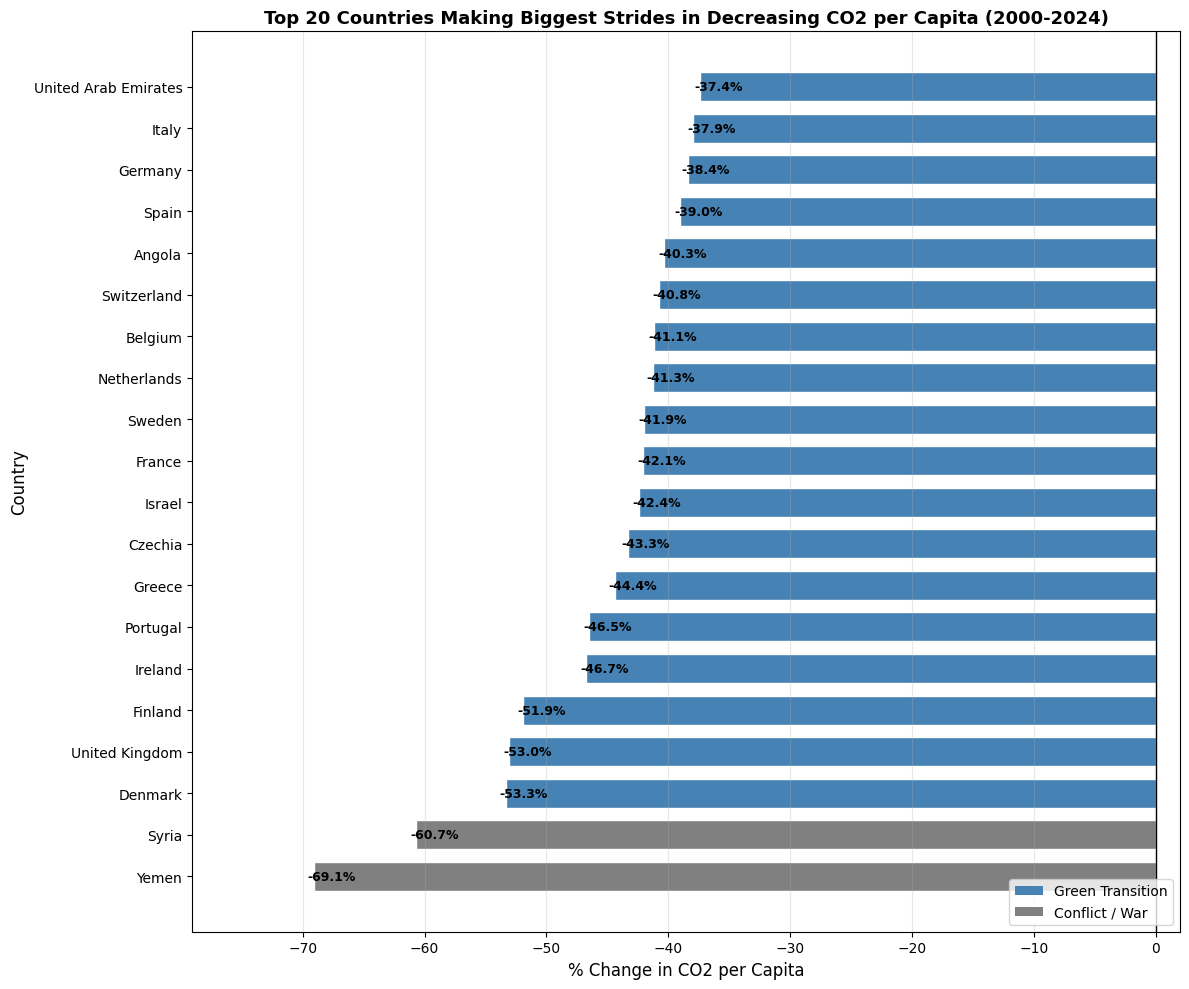

In [20]:
df_top20_all['Color'] = df_top20_all['Entity'].apply(
    lambda x: 'grey' if x in conflict_countries else 'steelblue'
)

df_top20_all = df_top20_all.sort_values('CO2_change_pct').copy()

fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(df_top20_all['Entity'], df_top20_all['CO2_change_pct'],
               color=df_top20_all['Color'], edgecolor='white', height=0.7)

# Reference line at 0
ax.axvline(x=0, color='black', linewidth=1)

# Add value labels OUTSIDE the left end of each bar
for bar, val in zip(bars, df_top20_all['CO2_change_pct']):
    ax.text(val - 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left', fontsize=9,
            color='black', fontweight='bold')

# Extend x-axis further left to make room for labels
ax.set_xlim(df_top20_all['CO2_change_pct'].min() - 10, 2)

# LEGEND
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Green Transition'),
    Patch(facecolor='grey', label='Conflict / War')
]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')

# FORMATTING

ax.set_title('Top 20 Countries Making Biggest Strides in Decreasing CO2 per Capita (2000-2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('% Change in CO2 per Capita', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


**Insight withhout outliers (conflicted countries)**

In [21]:
# Filter out conflict countries
df_no_conflict_plot = df_change_5m[~df_change_5m['Entity'].isin(conflict_countries)].copy()

# Get top 20 by CO2 decrease
df_top20_clean = df_no_conflict_plot.nsmallest(20, 'CO2_change_pct').copy()

print(df_top20_clean[['Entity', 'CO2_change_pct', 'Population_change_pct']].to_string())

                   Entity  CO2_change_pct  Population_change_pct
56                Denmark      -53.334705              11.943806
218        United Kingdom      -53.028852              17.069596
76                Finland      -51.879543               8.521969
101               Ireland      -46.731047              38.195744
169              Portugal      -46.484710               1.381818
84                 Greece      -44.389885              -6.814892
54                Czechia      -43.326456               4.875028
102                Israel      -42.425204              53.603618
77                 France      -42.050349              11.876898
200                Sweden      -41.949131              19.554504
146           Netherlands      -41.261538              13.512765
21                Belgium      -41.131632              14.505289
201           Switzerland      -40.797962              24.192306
5                  Angola      -40.314101             133.937317
196                 Spain

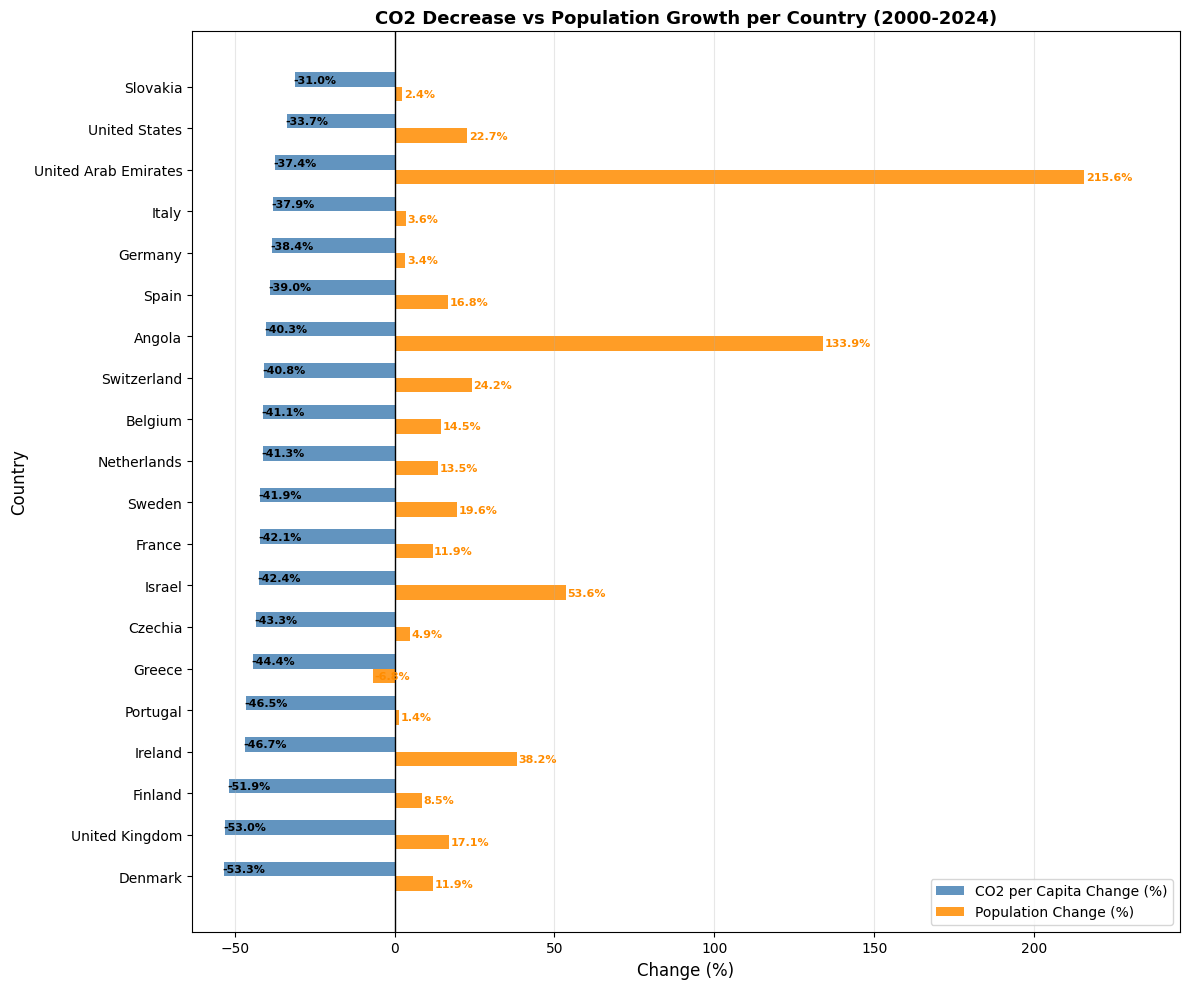

In [22]:
fig, ax = plt.subplots(figsize=(12, 10))

# SET UP BAR POSITIONS
countries = df_top20_clean['Entity'].tolist()
x = np.arange(len(countries))
width = 0.35

# PLOT BARS
bars1 = ax.barh(x + width/2, df_top20_clean['CO2_change_pct'],
                width, label='CO2 per Capita Change (%)',
                color='steelblue', alpha=0.85)

bars2 = ax.barh(x - width/2, df_top20_clean['Population_change_pct'],
                width, label='Population Change (%)',
                color='darkorange', alpha=0.85)

# VALUE LABELS
for bar, val in zip(bars1, df_top20_clean['CO2_change_pct']):
    ax.text(val - 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left',
            fontsize=8, color='black', fontweight='bold')

for bar, val in zip(bars2, df_top20_clean['Population_change_pct']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left',
            fontsize=8, color='darkorange', fontweight='bold')

# REFERENCE LINE AT 0
ax.axvline(x=0, color='black', linewidth=1)

# FORMATTING
ax.set_yticks(x)
ax.set_yticklabels(countries, fontsize=10)
ax.set_title('CO2 Decrease vs Population Growth per Country (2000-2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Change (%)', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, axis='x', alpha=0.3)

# Extend x-axis to fit population labels on right
ax.set_xlim(df_top20_clean['CO2_change_pct'].min() - 10,
            df_top20_clean['Population_change_pct'].max() + 30)

plt.tight_layout()
plt.show()

**Question 2: Which countries are making the biggest strides in decreasing CO2 output?**

**Conclusion:**
Based on the analysis of CO2 per capita change and population growth from 2000-2024 across all countries with a population above 5 million, the results fall into two distinct categories.

**Three important conclusions:**

**European countries lead the genuine green transition**
Denmark, UK and Finland have cut CO2 per capita by over 50% while growing their populations, driven by deliberate energy policy, coal phase-out and renewable investment.

**Population growth does not prevent CO2 reduction**
UAE and Angola demonstrate that even with extreme population growth of +216% and +134% respectively, CO2 per capita can still be significantly reduced through energy efficiency and cleaner energy sources.

**Conflict countries show the largest decreases but for the wrong reasons**
Yemen (-69%) and Syria (-61%) top the overall ranking but their reductions are driven by economic and infrastructure collapse due to war, not green transition. Their future trajectory will be an interesting test of the leapfrog hypothesis — whether rebuilding nations skip fossil fuel infrastructure and adopt renewables directly.